<a href="https://colab.research.google.com/github/katjia/ISPPD_TTE_workshop/blob/main/TTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Target Trial Emulation Workshop

<img src="https://drive.google.com/uc?export=view&id=1HgtK1egiUQ6Po0HTxwTXvg6g6_cE81UN" alt="drawing" width="400"/>

## May 17, 2026  <br> Kayoko Shioda, Katherine Jia, Kanako Fuyama

Expected completion time: 50 minutes


# Content
1.   Load and interpret data
2.   Cloning and censoring under each vaccine protocol
3.   Calculate censoring weights using the Cox proportional hazard model
4.   Visualize the distribution of weights
5.   Plot the cumulative incidence under each protocol
6.   Plot the risk ratios

# 1. Load and interpret data

We will compare two vaccine schedules (single dose vs. two doses)

<img src="https://drive.google.com/uc?export=view&id=1ZRwAdNdF7O0EvjBLvDcvHvkjP3EsdDpm" alt="drawing" width="600"/>


Our data are generated from an agent‑based susceptible–exposed–infectious–susceptible (S–E–I–S) transmission model developed by Kanako Fuyama. In the model, individuals who are exposed become infectious after 5 days and recover after 7 days, at which point they acquire infection‑induced immunity. This immunity provides 70% protection against infection and begins to wane 90 days after infection. Vaccination also provides protection against infection. Individuals who receive one dose gain 50% protection, which begins to decline 90 days after vaccination. Individuals who receive the second doses gain an additional 30% protection, which begins to wane 180 days after the second dose.

<img src="https://drive.google.com/uc?export=view&id=1IN40Ai8ESEtNUxIKLLgecSPc1AvZbEdz" alt="drawing" width="1000"/>

In the scenario shown here, 20% of individuals had received at least one vaccine dose. Among these vaccinated individuals, **50% received only the first dose, while the remaining 50% received a second dose after 28 days.** The epidemic curve is shown below:

<img src="https://drive.google.com/uc?export=view&id=16iFSOp6-QDNVG9V47u3DCCKT8D7n6OKU" alt="drawing" width="600"/>


🗓️ **The index date (i.e., Day 0) is the date when individuals receives Dose 1.**

💉 Our datasets includes n = 20,000 individuals who received Dose 1; 50% of these individuals also receive Dose 2, while the other 50% do not.

📊 Now, let's load the data and examine how it looks:

*   time.inf: Time to infection (in days) from receipt of dose 1 (**NA indicates no infection after dose 1**)
*   days.btw.doses.12: Number of days between dose 1 and dose 2 (**NA indicates no dose 2**)
*   days.btw.dose1.eofu: Number of days between dose 1 and the end of follow-up (EOFU).

In [11]:
# 1.1 Load data ----------------------------------------------------------------
my_data <- read.csv("https://github.com/katjia/ISPPD_TTE_workshop/raw/main/dat.csv")
head(my_data)

,ID,time.inf,days.btw.doses.12,days.btw.dose1.eofu
,<int>,<int>,<int>,<int>
1,3,NA,28,480
2,11,NA,28,480
3,21,NA,NA,480
4,23,183,28,480
5,25,NA,NA,480
6,31,NA,28,480


🔧 We will also install and load packages

In [12]:
# 1.2 Package setup ------------------------------------------------------------
install_missing_pkgs <- function(pkgs) {
  new_pkgs <- pkgs[!pkgs %in% installed.packages()[,"Package"]]

  if (length(new_pkgs) > 0) {
    install.packages(new_pkgs, dependencies = c("Depends","Imports"))
  }
}

load_pkgs <- function(pkgs) {
  invisible(lapply(pkgs, library, character.only = TRUE))
}

pkgs <- c(
  "dplyr",
  "tidyr",
  "data.table",
  "survival",
  "purrr",
  "future",
  "future.apply",
  "patchwork",
  "ggplot2"
)

install_missing_pkgs(pkgs)
load_pkgs(pkgs)

# 2. Cloning & censoring
**1. Cloning**: We create two "clones" of each individual under the two protocols:
1.   2-dose protocol: received two doses
2.   1-dose protocol: received only dose

❗️ Let's consider a toy example of two individuals (A and B):
   * Individual A received two doses.
   * Individual B received only one dose.

At the index date, we create **two clones for each individual.** This is because their observed data are compactible with both protocols at the index date.

<img src="https://drive.google.com/uc?export=view&id=1FBM8SaEUWRD8WHQ4KK7cgC2FdUiF8IDB" alt="drawing" width="600"/>

**2. Censoring**: Individuals are censored when they deviate from the assigned protocol.

🔍 Let's examine our toy example:
* Individual A received two doses.
   * Under the 2-dose protocol (green), her clone remained uncensored throughout follow-up.
   * Under the 1-dose protocol (purple), her clone was censored on the day she received Dose 2, since this deviates from the 1-dose strategy.

* Individual B received only one dose.
   * Under the 2-dose protocol, her clone was censored at the pre-specified time for receiving Dose 2, because she did not receive the second dose.
   * Under the 1-dose protocol (purple), her clone remained uncensored, and her outcome was counted under the 1-dose protocol.

**3. End of follow-up:** Each uncensored individual is followed up until **240 days after the index date**.

 🔍 Let’s look at the code used for cloning and censoring under the 2-dose protocol!

```
df_2_doses <- bootm %>%
  
  ### Step 1 for the 2-dose schedule ###
  # Calculate censoring time for each clone
  # CENSORING RULE for 2-dose protocol:
  # - Participants who never get dose 2 are CENSORED at day 28 (they didn't follow protocol)
  # - Participants who get dose 2 are followed until the end of the study period
  dplyr::mutate(censoring_time = case_when(
    
    #---Criteria 1---#
    # If never received dose 2: follow until Day 28
    is.na(days.btw.doses.12) ~ 28,
    
    #---Criteria 2---#                                                                
    # If received dose 2: follow until end of follow-up
    !is.na(days.btw.doses.12) ~ followup_period))
```

And now for the 1-dose protocol!
```
df_1_dose <- bootm %>%
      
      ### Step 1 for the 1-dose schedule ###
      # Calculate censoring time for each clone
      # CENSORING RULE for 1-dose protocol:
      # - Those who never get dose 2 are followed until end of study (they followed protocol)
      # - Those who get dose 2 are CENSORED at day 28 (they didn't follow the 1-dose protocol)
      dplyr::mutate(censoring_time = case_when(
        
        #---Criteria 1---#
        # If never received dose 2: follow until end of follow-up
        is.na(days.btw.doses.12) ~ followup_period,
        
        #---Criteria 2---#                                                                
        # If received dose 2: until Day 28 (day of receiving dose 2)
        !is.na(days.btw.doses.12) ~ 28))
```

# 3. Calculate censor weights

📝 We use the Cox proportional hazard (PH) model to estimate the probability of remaining recensored over time. In the code, the Cox PH model looks like:

```
coxph.censor <- survival::coxph(survival::Surv(dur_followup, censored) ~ 1, data = ...)
```

where
*   dur_followup: time until censoring (non-adherence or end-of-follow-up) or outcome
*   censored: 1 if censored, 0 if had outcome
*   ~ 1: null model (no covariates)

🥾 BOOTSTRAPPING is used construct confidence intervals. We randomly sample participants WITH REPLACEMENT `n_boot` times to estimate uncertainty in cumulative incidence curves.
*   Each iteration applies the full clone-censor-weight procedure.
*   We then calculate 95% CI from the 2.5th and 97.5th percentiles across iterations.


In [13]:
n_boot <- 500

# We follow up each individual until 240 days after dose 1
followup_period <- 240

# Create placeholders
all_cases_2_doses <- list()
all_cases_1_dose <- list()

all_res_2_doses <- list()
all_res_1_dose <- list()

💻 Let's run the CCW analysis! It involves 500 bootstrapped samples and takes ~ 3 minutes.

In [14]:
for(i in 1:n_boot){

# Set a seed for reproducibility
seed <- 788 + i

set.seed(seed)

bootm <- my_data[sample(1:dim(my_data)[1], replace=TRUE), ]

# 2.1 Cloning for the 2-dose schedule---------------------------------
df_2_doses <- bootm %>%

  ### Step 1 for the 2-dose schedule ###
  # Calculate censoring time for each clone
  # CENSORING RULE for 2-dose protocol:
  # - Participants who never get dose 2 are CENSORED at day 28 (they didn't follow protocol)
  # - Participants who get dose 2 are followed until the end of the study period
  dplyr::mutate(censoring_time = case_when(

    #---Criteria 1---#
    # If never received dose 2: follow until Day 28
    is.na(days.btw.doses.12) ~ 28,

    #---Criteria 2---#
    # If received dose 2: follow until end of follow-up
    !is.na(days.btw.doses.12) ~ followup_period))

    ### Create a function for Steps 2-4 ###
    compute_metrics <- function(df) {

      # Step 2: Determine if the outcome occurred BEFORE censoring for each clone
      df <- df %>%
        dplyr::mutate(outcome_before_censoring = case_when(
          # Outcome_before_censoring is 1 if the outcome occurred before
          # an individual was censored
          time.inf < censoring_time ~ 1,

          # Otherwise, the individual did not have an outcome, or the individual
          # had an outcome after censoring_time
          # For either case, outcome_before_censoring = 0.
          is.na(df$time.inf) | df$time.inf >= df$censoring_time ~ 0
        ))

      # Step 3: Determine the duration of follow up for each clone
      # The follow-up duration "dur_followup" is the time from dose 1 until either:
      # - censoring_time (censoring occurs due to non-adherence to the specified protocol) OR
      # - time.inf (outcome occurred before censoring)
      df$dur_followup <- df$censoring_time

      df$dur_followup[!is.na(df$outcome_before_censoring) & df$outcome_before_censoring == 1L] <-
        df$time.inf[!is.na(df$outcome_before_censoring) & df$outcome_before_censoring == 1L]

      ### Step 4: Create censoring indicator variable
      # This indicator is used in the Cox model for censoring weights
      # censored = 1: The clone was censored due to the protocol non-adherence or the end of follow up
      # censored = 0: otherwise
      df$censored <- as.integer(df$outcome_before_censoring == 0L)

      df
    }

    df_2_doses <- compute_metrics(df_2_doses)

    # Label protocol group
    df_2_doses$protocol <- "2 doses"

# 2.2 Cloning for the 1-dose schedule----------------------------
df_1_dose <- bootm %>%

      ### Step 1 for the 1-dose schedule ###
      # Calculate censoring time for each clone
      # CENSORING RULE for 1-dose protocol:
      # - Those who never get dose 2 are followed until end of study (they followed protocol)
      # - Those who get dose 2 are CENSORED at day 28 (they didn't follow the 1-dose protocol)
      dplyr::mutate(censoring_time = case_when(

        #---Criteria 1---#
        # If never received dose 2: follow until end of follow-up
        is.na(days.btw.doses.12) ~ followup_period,

        #---Criteria 2---#
        # If received dose 2: until Day 28 (day of receiving dose 2)
        !is.na(days.btw.doses.12) ~ 28))

    ### Steps 2-4 ###
    df_1_dose <- compute_metrics(df_1_dose)

    # Label protocol group
    df_1_dose$protocol <- "1 dose"

    # Define the outcome at dur_followup under each protocol:
    # clone.outcome=1 if a clone had an outcome before censoring under each protocol
    # clone.outcome=0 otherwise.
    df_2_doses$clone.outcome <- as.integer(df_2_doses$outcome_before_censoring == 1)
    df_1_dose$clone.outcome <- as.integer(df_1_dose$outcome_before_censoring == 1)

# 3 Compute the inverse probability of censoring weight (IPCW) for each clone under each protocol --------------

    # We use the Cox proportional hazard model to estimate the probability of remaining recensored over time
    # We fit a Cox proportional hazards model where the "event" is CENSORING (not outcome)
    # Model: Surv(dur_followup, censored) ~ 1
    #   - dur_followup: time until censoring (non-adherence or EOFU) or outcome
    #   - censored: 1 if censored, 0 if had outcome
    #   - ~ 1: null model (no covariates), estimates baseline censoring hazard only

  # 3.1 Censoring weights for 2-dose protocol ----------------------------------

      coxph.censor <- survival::coxph(survival::Surv(dur_followup, censored) ~ 1, data = df_2_doses)

      # Subset the clone population to just those who had the outcome
      # because those who did not have the outcome do not contribute to the calculation
      # of the cumulative incidence of outcome.
      cases <- df_2_doses[df_2_doses$clone.outcome==1,]

      # Predict the probability of remaining uncensored at each person’s event time
      # (date of the outcome).
      # For a null Cox model, use baseline hazard
      bh <- survival::basehaz(coxph.censor, centered = FALSE)
      expected_vals <- approx(bh$time, bh$hazard, xout = cases$dur_followup, rule = 2)$y
      cases_2_doses <- cases %>%
        dplyr::mutate(.fitted = expected_vals,
                      prob = exp(-.fitted))

      # Order the subset data by the event time
      cases_2_doses <- cases_2_doses[order(cases_2_doses$dur_followup),]

      # Compute the inverse probability censoring weights
      cases_2_doses$wt <- 1/cases_2_doses$prob

      # Create time data
      cases_2_doses <- cases_2_doses %>%
        subset(., select = c(ID, wt, dur_followup, protocol))

      cases_2_doses <- cbind(cases_2_doses,
                             sim=i)

      cases_2_doses <- data.frame(dur_followup=seq(1, followup_period, 1)) %>%
        left_join(., cases_2_doses, by = "dur_followup")

      # At each time t: Cumulative Incidence(t) = Cumulative sum of weighted cases / Total population size
      # This accounts for censoring by upweighting cases who were uncensored
      # This gives us our cumulative incidence curve
      cases_2_doses$risk <- cumsum(tidyr::replace_na(cases_2_doses$wt, 0)) / nrow(df_2_doses)

      res_2_doses <- cases_2_doses[which(cases_2_doses$dur_followup <= followup_period),] %>%
        dplyr::group_by(dur_followup) %>%
        dplyr::summarise(cumrisk = max(risk, na.rm=TRUE))

      # Add the protocol column
      res_2_doses$protocol <- "2 doses"
      cases_2_doses$protocol <- "2 doses"

      # Note iteration
      res_2_doses$sim <- i

      # Combine results across all simulations
      all_res_2_doses <- rbind(all_res_2_doses, res_2_doses)

      # Save the patient-level weights
      all_cases_2_doses <- rbind(all_cases_2_doses, cases_2_doses)

      # 3.2 Censoring weights for 1-dose protocol ------------------------------

      coxph.censor <- survival::coxph(survival::Surv(dur_followup, censored) ~ 1, data = df_1_dose)

      # Subset the clone population to just those who had the outcome
      # because those who did not have the outcome do not contribute to the calculation
      # of the cumulative risk of outcome.
      cases <- df_1_dose[df_1_dose$clone.outcome==1,]

      # Predict the probability of remaining uncensored at each person’s event time
      # (date of the outcome).
      # For a null Cox model, use baseline hazard
      bh <- survival::basehaz(coxph.censor, centered = FALSE)
      expected_vals <- approx(bh$time, bh$hazard, xout = cases$dur_followup, rule = 2)$y
      cases_1_dose <- cases %>%
        dplyr::mutate(.fitted = expected_vals,
                      prob = exp(-.fitted))

      # Order the subset data by the event time
      cases_1_dose <- cases_1_dose[order(cases_1_dose$dur_followup),]

      # Compute the inverse probability censoring weights
      cases_1_dose$wt <- 1/cases_1_dose$prob

      # Create time data
      cases_1_dose <- cases_1_dose %>%
        subset(., select = c(ID, wt, dur_followup, protocol))

      cases_1_dose <- cbind(cases_1_dose,
                             sim=i)

      cases_1_dose <- data.frame(dur_followup=seq(1, followup_period, 1)) %>%
        left_join(., cases_1_dose, by = "dur_followup")

      # This gives us our cumulative incidence curve
      cases_1_dose$risk <- cumsum(tidyr::replace_na(cases_1_dose$wt, 0)) / nrow(df_1_dose)

      res_1_dose <- cases_1_dose[which(cases_1_dose$dur_followup <= followup_period),] %>%
        dplyr::group_by(dur_followup) %>%
        dplyr::summarise(cumrisk = max(risk, na.rm=TRUE))

      # Add the protocol column
      res_1_dose$protocol <- "1 dose"
      cases_1_dose$protocol <- "1 dose"

      # Note iteration
      res_1_dose$sim <- i

      # Combine results across all simulations
      all_res_1_dose <- rbind(all_res_1_dose, res_1_dose)

      # Save the patient-level weights
      all_cases_1_dose <- rbind(all_cases_1_dose, cases_1_dose)

    # clean up
    rm(df_2_doses)
    rm(df_1_dose)

    rm(res_2_doses)
    rm(res_1_dose)

    rm(cases_2_doses)
    rm(cases_1_dose)
}


# 4. Visualize the distribution of weights

* Censoring weights are defined as the inverse of the probability of remaining uncensored under a given protocol (1-dose or 2-dose). In this step, we focus only on individuals who experienced the outcome **(cases)**.

* How to interpret weights (for cases)
   * Weight = 1: The individual experienced the outcome before Day 28 (the pre-specified time for receiving Dose 2)
   * Weight = 2: The individual experienced the outcome after Day 28
   * ❗️ Why weight = 2? This is because, by design, 50% of individuals follow the 1-dose protocol and 50% follow the 2-dose protocol. Under a specific protocol (e.g., 1-dose), only 50% individuals remain uncensored after Day 28. **Our causal question is: What if the entire target population had followed the specific protocol? To make up for the other half who were censored, these uncensored individuals are upweighted by 2.**

🔍 Visualizing the weights

* To explore the distribution of weights, we randomly select **three simulations out of the 500 (simulations 179, 415, and 463)** and examine the weights assigned to individuals under each protocol.




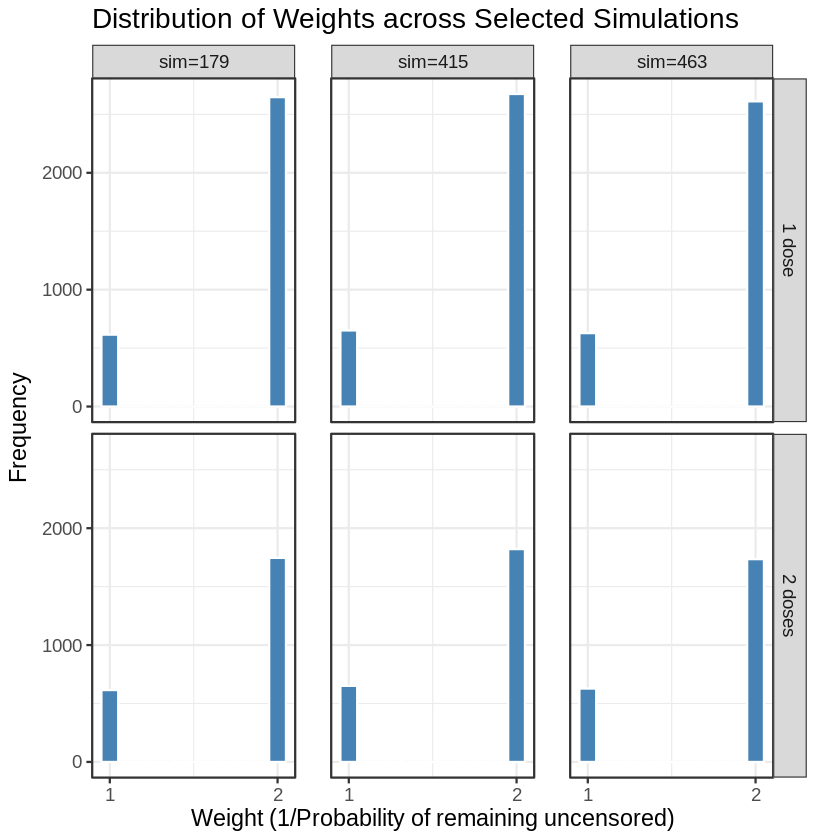

In [15]:
# 4. Visualize the distribution of weights -------------------------------------
all_cases <- rbind(all_cases_2_doses,
                   all_cases_1_dose)

# Remove rows with NA weights (time points with no events)
all_cases_clean <- all_cases %>%
  filter(!is.na(wt))

# Randomly select 3 simulations
set.seed(123)
available_sims <- unique(all_cases_clean$sim)
selected_sims <- sample(available_sims, 3)

# Filter to only the selected simulations
all_cases_selected <- all_cases_clean %>%
  filter(sim %in% selected_sims)

# Visualize the distribution of the inverse probability weights
# 2x3 grid: upper row for 1 dose, lower row for 2 doses, columns for each sim
ggplot(all_cases_selected, aes(x = wt)) +
  geom_histogram(fill = "steelblue", color = "white", binwidth = 0.1) +
  labs(
    title = "Distribution of Weights across Selected Simulations",
    x = "Weight (1/Probability of remaining uncensored)",
    y = "Frequency"
  ) +
  theme_bw(base_size = 14) +
  facet_grid(protocol ~ sim, labeller = labeller(sim = function(x) paste0("sim=", x))) +
  scale_x_continuous(breaks = c(1, 2)) +
  coord_cartesian(clip = "off") +
  theme(plot.margin = margin(5.5, 20, 5.5, 5.5),
        panel.spacing.x = unit(1.5, "lines"))


* Across the simulations, the number of cases with weight = 1 is the same under both protocols (n~600). This is expected because **the 1-dose and 2-dose protocols are identical before Day 28**, so they have the same number of cases occurring before that time.

* The protocols begin to differ after Day 28. The 1-dose  protocol has more cases than the 2-dose protocol, which leads to **a higher frequency of weight = 2 **under the 1-dose protocol.

* EXTRA note: In some situations, a small number of cases can take on extremely large weights, which may disproportionately influence the results and lead to wide confidence interval. It is common to truncate the weights at the 1st and 99th percentiles. For more information, please refer to Cole & Hernan 2008 (https://pubmed.ncbi.nlm.nih.gov/18682488/).

# 5. Plot the cumulative incidence under each schedule

🔢 The cumulative incidence under the 1-dose (or 2-dose) protocol is calculated as:

$$\frac{\text{Cumulative weighted sum of uncensored cases}}{\text{Total population size}}$$

❗️ What each part means
* Denominator = total population size (n = 20,000)
  * This is because we have created a hypothetical population in which all individuals are assigned to the 1-dose protocol (or 2-dose) at the index date.
* Numerator = cumulative weighted sum of uncensored cases
  * Only uncensored cases contribute to the numerator. We upweighted the uncensored cases to account for censoring (i.e., cases who remain uncensored are upweighted to represent those who were censored).

👩‍💻 How this is implemented in R

```
cases_1_dose$risk <- cumsum(tidyr::replace_na(cases_1_dose$wt, 0)) / nrow(df_1_dose)
```
   * where
     * wt = weight assigned to each uncensored case
     * cumsum(...) = cumulative sum over time
     * nrow(df_1_dose) = total population size (20,000)

Note: The same calculation is applied to the 2-dose protocol.

🎨 Let's plot the cumulative incidence curve!

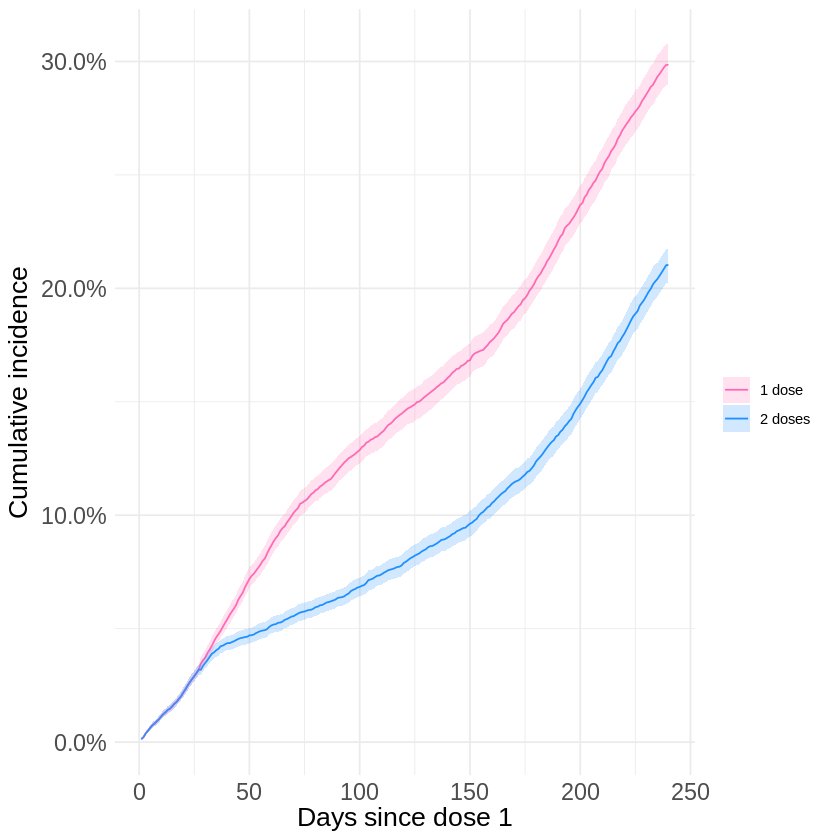

In [16]:
all_data <- rbind(all_res_2_doses,
                  all_res_1_dose)

# Calculate median and 95% credible intervals by region
summary_data <- all_data %>%
  group_by(protocol, dur_followup) %>%
  summarize(
    median = quantile(cumrisk, 0.5, na.rm = T),
    lb = quantile(cumrisk, 0.025, na.rm = T),
    ub = quantile(cumrisk, 0.975, na.rm = T),
    .groups = "drop"
  )

ggplot(
  summary_data,
  aes(x = dur_followup, y = median, color = protocol, fill = protocol)
) +
  geom_line() +
  geom_ribbon(aes(ymin = lb, ymax = ub), alpha = 0.2, color = NA) +
  theme_minimal() +
  labs(
    x = "Days since dose 1",
    y = "Cumulative incidence",
    color = " ",
    fill  = " "
  ) +
  scale_color_manual(
    values = c("2 doses" = "dodgerblue",
               "1 dose" = "hotpink"),
    labels = c("2 doses" = "2 doses",
               "1 dose" = "1 dose")
  ) +
  scale_fill_manual(
    values = c("2 doses" = "dodgerblue",
               "1 dose" = "hotpink"),
    labels = c("2 doses" = "2 doses",
               "1 dose" = "1 dose")
  ) +
  scale_y_continuous(labels = scales::label_percent(
    accuracy = 0.1
  )) +
  theme(axis.title = element_text(size = 16),
        axis.text = element_text(size = 14))


* As expected, the cumulative incidence is higher under the 1-dose protocol, because the second dose provides an additional 30% protection.

# 6. Calculate/visualize the risk ratio

* Finally, we estimate the risk ratio, defined as:

$$\frac{\text{Cumulative incidence under the 2-dose protocol}}{\text{Cumulative incidence under the 1-dose protocol}}$$

* This compares the risk of the outcome if everyone had followed the 1-dose protocol versus if everyone had followed the 2-dose protocol.
* A risk ratio > 1 indicates higher risk under the 1-dose protocol, while a risk ratio < 1 indicates lower risk compared to the 2-dose protocol. As expected, the risk ratio > 1.

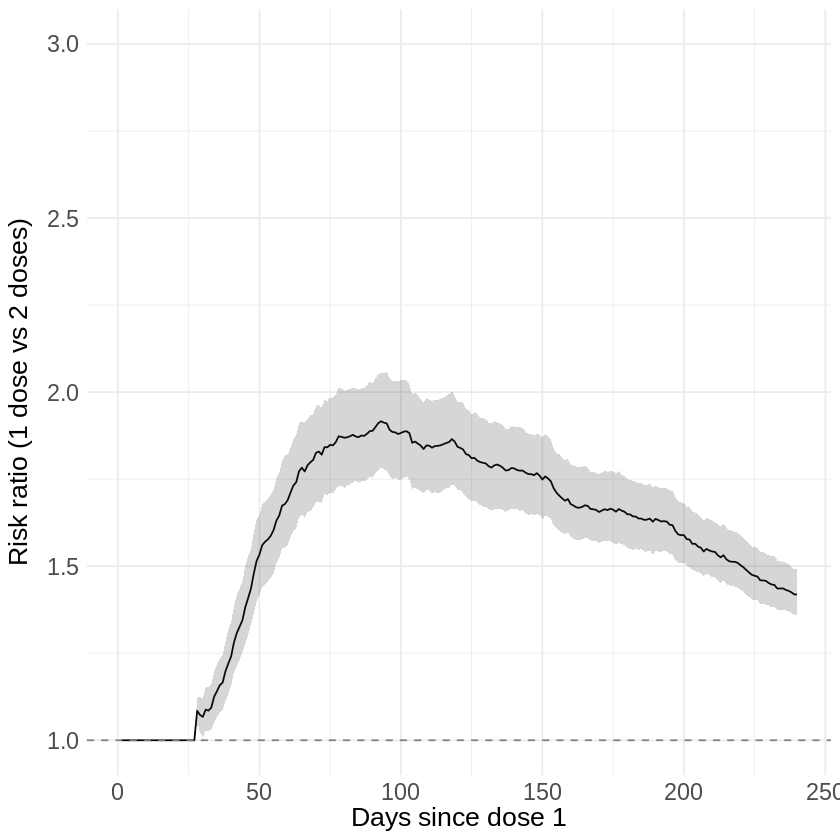

In [17]:
RR_time_series <- all_data %>%
  select(dur_followup, sim, protocol, cumrisk) %>%
  pivot_wider(
    names_from  = protocol,
    values_from = cumrisk
  ) %>%
  mutate(
    RR = `1 dose`/`2 doses`) %>%
  group_by(dur_followup) %>%
  summarize(
    RR_median = quantile(RR, 0.5, na.rm=T),
    RR_lb = quantile(RR, 0.025, na.rm=T),
    RR_ub = quantile(RR, 0.975, na.rm=T),
    .groups = "drop"
  )

ggplot(
  RR_time_series %>%
    select(
      dur_followup,
      median = RR_median,
      lb     = RR_lb,
      ub     = RR_ub
    ),
  aes(x = dur_followup, y = median)
) +
  geom_line() +
  geom_ribbon(aes(ymin = lb, ymax = ub), alpha = 0.2, color = NA) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "grey50") +
  theme_minimal() +
  labs(
    x = "Days since dose 1",
    y = "Risk ratio (1 dose vs 2 doses)"
  ) +
  scale_y_continuous(limits = c(NA, 3)) +
  theme(axis.title = element_text(size = 16),
        axis.text = element_text(size = 14))